# Module 14 — Capstone: An End-to-End Credit Decisioning Engagement

Everything from Modules 00–13, run once, in order, on a real-shaped problem —
with the decisions made explicitly rather than by default.

The brief:

> A mid-size lender wants to replace a manual underwriting screen with a model
> that ranks consumer loan applications by 36-month default risk. It will be
> deployed as a decision-support tool, must satisfy internal model risk
> management, and will be reviewed by a fair-lending committee. We have three
> years of application and outcome data.

Work through it as a sequence of decisions. **The deliverable at the end is a
one-page memo, not a model** — which is the right way round.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, plot_calibration, plot_pr_roc, set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 50)
warnings.filterwarnings("ignore", category=FutureWarning)
rng = np.random.default_rng(0)
RANDOM_STATE = 0

## Step 1 — Frame the problem before touching the data

Three questions, answered in writing, before any modelling.

**What decision does this change?** Applications above a risk cut-off go to
manual review or are declined. So the model needs to produce a *ranking* and a
defensible *cut-off* — not a label.

**What does each error cost?**

| Error | What happens | Cost |
|---|---|---|
| False negative — approve, then default | ~40% loss on a £15k average principal | **£6,000** |
| False positive — decline a good customer | forgone margin over the loan life | **£1,800** |

A 3.3:1 asymmetry. Note that both numbers had to be argued for with the
business — and that the *ratio* is what matters, not the absolute figures.
Getting the ratio wrong by a factor of three moves the optimal threshold a
long way, so this is a conversation to have properly rather than a parameter
to assume. The default 0.5 threshold is wrong before we start (Module 08).

**What is the deployment scenario?** New applicants, scored forward in time,
one row each. So: no group structure to worry about, but **temporal validation
is mandatory** (Module 04), and the model must be calibrated because the
threshold is derived from a cost ratio.

**The metric hierarchy** that follows:

1. **Primary:** expected cost per application at the chosen threshold.
2. **Ranking:** average precision (the positive class is 13%, so PR over ROC).
3. **Calibration:** Brier and the mean-predicted-vs-observed gap.
4. **Constraints:** monotonicity where domain sense demands it; four-fifths
   selection-rate ratio across age bands and regions; single-row latency < 50 ms.

In [2]:
COST_FN, COST_FP, MARGIN = 6_000.0, 1_800.0, 1_800.0
THEORETICAL_THRESHOLD = COST_FP / (COST_FP + COST_FN)
print(f"cost-optimal threshold for a calibrated model: {THEORETICAL_THRESHOLD:.4f}")

cost-optimal threshold for a calibrated model: 0.2308


## Step 2 — Data audit

Before modelling: what is in here, what is missing, and what should not be
here at all.

In [3]:
credit = load_credit_risk().sort_values("application_month").reset_index(drop=True)
print(f"{len(credit):,} applications, {credit['application_month'].min()} to {credit['application_month'].max()}")
print(f"overall default rate: {credit['default'].mean():.4f}")

from skmastery import describe_frame

describe_frame(credit)

12,000 applications, 2022-01 to 2024-12
overall default rate: 0.1326


,dtype,missing_%,n_unique,sample
column,,,,
application_id,str,0.00,12000,"APP009860, APP005219, APP000924, …"
application_month,str,0.00,36,"2022-01, 2022-02, 2022-03, …"
age,int64,0.00,67,"27, 36, 31, …"
employment_years,float64,13.89,296,"5.0, 15.2, 0.3, …"
annual_income,float64,1.68,1005,"25100.0, 45000.0, 19400.0, …"
loan_amount,float64,0.00,714,"4100.0, 27200.0, 5100.0, …"
term_months,int64,0.00,5,"12, 24, 36, 48, 60"
interest_rate,float64,0.00,861,"14.79, 16.21, 15.33, …"
debt_to_income,float64,0.00,5598,"0.3489, 0.3259, 0.1932, …"


by year:
                   size    mean
application_month              
2022               2727  0.1107
2023               3923  0.1175
2024               5350  0.1548


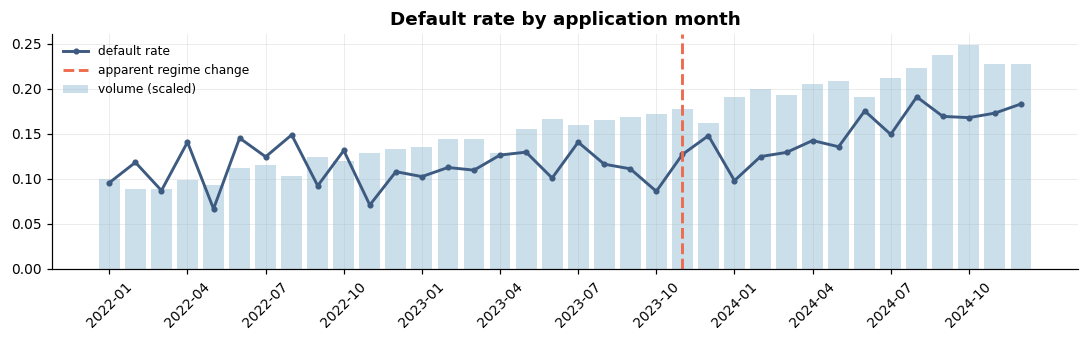

In [4]:
# Default rate over time -- the first thing to look at on any dated dataset.
by_month = credit.groupby("application_month").agg(n=("default", "size"), rate=("default", "mean"))
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(by_month.index, by_month["n"] / by_month["n"].max() * by_month["rate"].max() * 1.3, color="#98c1d9", alpha=0.5, label="volume (scaled)")
ax.plot(by_month.index, by_month["rate"], marker="o", ms=3, color="#3d5a80", label="default rate")
ax.axvline("2023-11", ls="--", color="#ee6c4d", label="apparent regime change")
ax.set_xticks(by_month.index[::3])
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.set_title("Default rate by application month")
plt.tight_layout()

print("by year:")
print(credit.groupby(credit.application_month.str[:4])["default"].agg(["size", "mean"]).round(4).to_string())

**Finding 1.** The default rate rises materially in the final year. Whatever
we build must be validated forward in time, and the reported performance must
come from the drifted period — not from a random split that averages over it.

In [5]:
# Leakage hunt: which single features are suspiciously predictive on their own?
from skmastery import leakage_report

candidates = credit.drop(columns=["default", "application_id"])
leakage_report(candidates, credit["default"], top=8)

,feature,kind,univariate_auc
0,collections_flag,numeric,0.934401
1,credit_score,numeric,0.738841
2,interest_rate,numeric,0.738114
3,debt_to_income,numeric,0.722802
4,term_months,numeric,0.601720
5,application_month,categorical,0.577217
6,loan_amount,numeric,0.568916
7,annual_income,numeric,0.564039


**Finding 2.** `collections_flag` scores ~0.93 AUC on its own — nearly as high
as any model we could build. That is the signature of leakage, and the
provenance check confirms it: the servicing system writes that flag *after* an
account goes to collections, so it is not available at application time.

**It comes out.** So does `application_id` (a sequential identifier that
encodes time) and `application_month` (a time key that belongs in the splitter,
not the features).

In [6]:
DROP = ["default", "application_id", "collections_flag", "application_month"]
FEATURES = [c for c in credit.columns if c not in DROP]

# The endogeneity note, which is subtler and does NOT mean dropping the column.
print("interest_rate vs credit_score correlation:",
      round(credit[["interest_rate", "credit_score"]].corr().iloc[0, 1], 3))
print("\ninterest_rate was SET by an existing risk-based pricing model that saw")
print("the same bureau data. It is legitimately available at decision time, so we")
print("keep it -- but it is partly a proxy for the incumbent model's opinion, and")
print("the model documentation must say so. Exercise 14.2 quantifies the effect.")

interest_rate vs credit_score correlation: -0.736

interest_rate was SET by an existing risk-based pricing model that saw
the same bureau data. It is legitimately available at decision time, so we
keep it -- but it is partly a proxy for the incumbent model's opinion, and
the model documentation must say so. Exercise 14.2 quantifies the effect.


## Step 3 — Validation design

Two layers, decided now and not revisited:

- **Development:** `TimeSeriesSplit` over the first 24 months, for every model
  selection decision.
- **Final holdout:** the last 12 months, touched **exactly once**, at the end.

The holdout discipline is the part that requires actual willpower. Write down
now that you will score it once.

In [7]:
from sklearn.model_selection import TimeSeriesSplit

dev_mask = credit["application_month"] < "2024-01"
X_dev, y_dev = credit.loc[dev_mask, FEATURES], credit.loc[dev_mask, "default"]
X_hold, y_hold = credit.loc[~dev_mask, FEATURES], credit.loc[~dev_mask, "default"]

cv = TimeSeriesSplit(n_splits=5)
print(f"development : {len(X_dev):,} rows, base rate {y_dev.mean():.4f}")
print(f"holdout     : {len(X_hold):,} rows, base rate {y_hold.mean():.4f}   <- note the shift")

development : 6,650 rows, base rate 0.1147
holdout     : 5,350 rows, base rate 0.1548   <- note the shift


## Step 4 — Baselines, and the noise floor

Never start with the sophisticated model. Establish what "no model" and "the
simplest model" achieve, and measure how much fold-to-fold variation there is,
so you can tell real improvements from noise (Module 04).

In [8]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_prep():
    """A fresh preprocessing block. Never share a fitted instance (Module 12)."""
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("sc", StandardScaler())]),
         make_column_selector(dtype_include=[np.number, "bool"])),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False))]),
         make_column_selector(dtype_include=["object", "string"])),
    ])


def expected_cost(y_true, y_score, threshold):
    tn, fp, fn, tp = confusion_matrix(y_true, (y_score >= threshold).astype(int), labels=[0, 1]).ravel()
    return (fn * COST_FN + fp * COST_FP) / len(y_true)


def evaluate(name, est, X=X_dev, y=y_dev):
    res = cross_validate(est, X, y, cv=cv, scoring=["average_precision", "roc_auc", "neg_brier_score"], n_jobs=-1)
    return {"model": name,
            "avg_precision": round(res["test_average_precision"].mean(), 4),
            "ap_std": round(res["test_average_precision"].std(), 4),
            "roc_auc": round(res["test_roc_auc"].mean(), 4),
            "brier": round(-res["test_neg_brier_score"].mean(), 5),
            "fit_s": round(res["fit_time"].mean(), 2)}


leaderboard = [
    evaluate("0. always-negative", DummyClassifier(strategy="most_frequent")),
    evaluate("1. stratified random", DummyClassifier(strategy="stratified", random_state=0)),
    evaluate("2. credit_score alone", Pipeline([
        ("sel", ColumnTransformer([("s", SimpleImputer(strategy="median"), ["credit_score"])])),
        ("clf", LogisticRegression(max_iter=1000))])),
    evaluate("3. logistic, all features", Pipeline([("prep", make_prep()), ("clf", LogisticRegression(max_iter=4000, C=0.3))])),
    evaluate("4. gradient boosting", Pipeline([("prep", make_prep()),
                                               ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06))])),
]
pd.DataFrame(leaderboard).set_index("model")

,avg_precision,ap_std,roc_auc,brier,fit_s
model,,,,,
0. always-negative,0.1161,0.0081,0.5000,0.11606,0.00
1. stratified random,0.1154,0.0067,0.4940,0.21245,0.00
2. credit_score alone,0.3363,0.0304,0.7421,0.09139,0.02
"3. logistic, all features",0.3917,0.0356,0.7609,0.08776,0.05
4. gradient boosting,0.3351,0.0324,0.7137,0.09991,1.02


Read this as a value-added chain: how much does each step of sophistication
buy over the one before? `credit_score` alone already captures a large share of
what the full model achieves — a fact worth knowing before proposing a
thirty-feature model, and worth telling the client.

In [9]:
# The noise floor: how much do these numbers move on repeated resampling?
from sklearn.model_selection import RepeatedStratifiedKFold

rep = cross_validate(
    Pipeline([("prep", make_prep()), ("clf", LogisticRegression(max_iter=4000, C=0.3))]),
    X_dev, y_dev, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=0),
    scoring="average_precision", n_jobs=-1,
)["test_score"]
NOISE_FLOOR = rep.std()
print(f"average precision over 30 splits: {rep.mean():.4f} ± {NOISE_FLOOR:.4f}")
print(f"→ differences smaller than ~{2 * NOISE_FLOOR:.4f} AP are not results.")

average precision over 30 splits: 0.4004 ± 0.0299
→ differences smaller than ~0.0599 AP are not results.


## Step 5 — Candidate models, with the constraints applied

Model risk management will require monotonicity in the obvious directions.
Apply the constraint now and measure what it costs, rather than discovering
later that the chosen model violates it.

In [10]:
# Domain-mandated directions. Every one of these would be challenged if violated.
MONOTONE = {
    "credit_score": -1,      # higher score -> lower risk
    "debt_to_income": +1,    # more leverage -> higher risk
    "n_delinq_2yr": +1,      # more past delinquency -> higher risk
    "interest_rate": +1,     # priced riskier -> riskier
    "annual_income": -1,     # more income -> lower risk
}

num_cols = [c for c in FEATURES if pd.api.types.is_numeric_dtype(credit[c]) and not pd.api.types.is_bool_dtype(credit[c])]
cat_cols = [c for c in FEATURES if c not in num_cols]

# For monotonic constraints we need a stable, known column order, so build the
# preprocessing explicitly rather than with a selector.
mono_prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False), cat_cols),
], verbose_feature_names_out=False)
mono_prep.fit(X_dev)
out_names = list(mono_prep.get_feature_names_out())
cst = [MONOTONE.get(n, 0) for n in out_names]
print(f"{sum(1 for c in cst if c != 0)} of {len(out_names)} output features carry a monotonic constraint")

candidates = {
    "A. logistic (C=0.3)": Pipeline([("prep", make_prep()), ("clf", LogisticRegression(max_iter=4000, C=0.3))]),
    "B. logistic + balanced": Pipeline([("prep", make_prep()), ("clf", LogisticRegression(max_iter=4000, C=0.3, class_weight="balanced"))]),
    "C. boosting (free)": Pipeline([("prep", make_prep()), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06, max_leaf_nodes=15))]),
    "D. boosting + monotone": Pipeline([("prep", mono_prep), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06, max_leaf_nodes=15, monotonic_cst=cst))]),
}
pd.DataFrame([evaluate(k, v) for k, v in candidates.items()]).set_index("model")

5 of 35 output features carry a monotonic constraint


,avg_precision,ap_std,roc_auc,brier,fit_s
model,,,,,
A. logistic (C=0.3),0.3917,0.0356,0.7609,0.08776,0.05
B. logistic + balanced,0.3912,0.0375,0.7579,0.18972,0.05
C. boosting (free),0.3412,0.0270,0.7178,0.09592,0.66
D. boosting + monotone,0.3464,0.0363,0.7243,0.09542,0.71


## Step 6 — Select on cost, not on AP

The leaderboard above ranks by ranking quality. The decision is made on money.
Score each candidate on out-of-fold predictions and convert to expected cost
at its own optimal threshold (Module 08).

In [11]:
from sklearn.base import clone


def walk_forward_oof(est, X, y, cv):
    """Out-of-fold predictions for a NON-partitioning splitter.

    `cross_val_predict` refuses `TimeSeriesSplit`, and correctly so: the folds
    are not a partition (the first block is never a test set, and with a gap
    some rows are never scored). Rows with no prediction stay NaN.
    """
    oof = np.full(len(X), np.nan)
    for tr, te in cv.split(X):
        m = clone(est).fit(X.iloc[tr], y.iloc[tr])
        oof[te] = m.predict_proba(X.iloc[te])[:, 1]
    return oof


thresholds = np.linspace(0.01, 0.6, 240)
econ = []
for name, est in candidates.items():
    oof = walk_forward_oof(est, X_dev, y_dev, cv)
    scored = ~np.isnan(oof)              # the first block is never a test fold
    yy, pp = y_dev[scored], oof[scored]
    costs = np.array([expected_cost(yy, pp, t) for t in thresholds])
    best = costs.argmin()
    econ.append({
        "model": name,
        "avg_precision": round(average_precision_score(yy, pp), 4),
        "brier": round(brier_score_loss(yy, pp), 5),
        "mean_pred": round(pp.mean(), 4),
        "observed": round(yy.mean(), 4),
        "best_threshold": round(thresholds[best], 4),
        "cost_at_best": round(costs[best], 1),
        "cost_at_0.5": round(expected_cost(yy, pp, 0.5), 1),
    })
econ_df = pd.DataFrame(econ).set_index("model")
econ_df

,avg_precision,brier,mean_pred,observed,best_threshold,cost_at_best,cost_at_0.5
model,,,,,,,
A. logistic (C=0.3),0.3841,0.08776,0.1157,0.1161,0.2297,543.9,615.1
B. logistic + balanced,0.3824,0.18972,0.4041,0.1161,0.6000,593.1,679.0
C. boosting (free),0.3275,0.09592,0.0931,0.1161,0.2322,562.4,620.4
D. boosting + monotone,0.3359,0.09542,0.1025,0.1161,0.2470,558.0,612.5


Four things to read off that table.

1. **The threshold matters more than the model.** The gap between
   `cost_at_0.5` and `cost_at_best` for any single model dwarfs the spread of
   `cost_at_best` across all four.
2. **`class_weight="balanced"` wrecks calibration** — compare its `mean_pred`
   (≈0.40) to `observed` (≈0.12). Its cost-optimal threshold lands somewhere
   strange as a result, and any expected-loss figure derived from it would be
   wrong by a factor of three.
3. **The logistic model wins, and not by a trivial margin.** It beats both
   boosted variants by ~0.05 average precision, which is close to two noise-floor
   widths. This has been the pattern in every module of this curriculum on this
   dataset, and it deserves to be stated plainly rather than explained away: the
   generating process is largely additive in the log-odds, which is exactly what
   a logistic regression represents and exactly what a tree ensemble has to
   reconstruct from axis-aligned splits.
4. **The monotonic constraint costs almost nothing** *within* the boosted family
   (C vs D). That is the number to quote when someone argues the constraint is
   too expensive — but here it is an argument about the losing family.

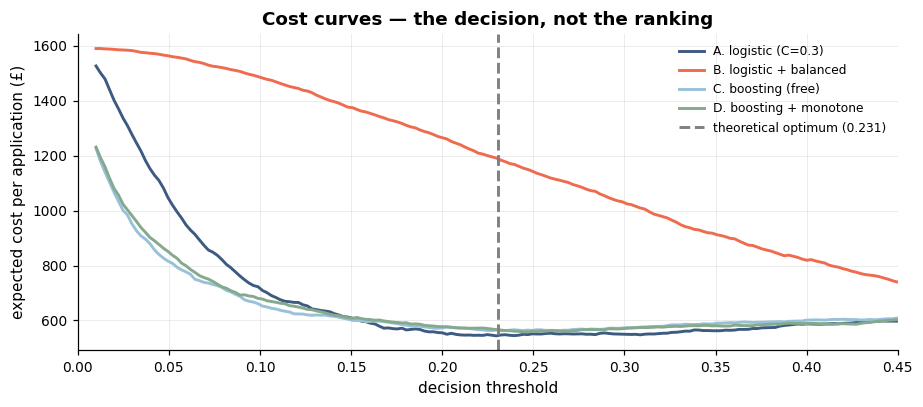

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for name, est in candidates.items():
    oof = walk_forward_oof(est, X_dev, y_dev, cv)
    m = ~np.isnan(oof)
    ax.plot(thresholds, [expected_cost(y_dev[m], oof[m], t) for t in thresholds], label=name)
ax.axvline(THEORETICAL_THRESHOLD, ls="--", color="0.5", label=f"theoretical optimum ({THEORETICAL_THRESHOLD:.3f})")
ax.set(xlabel="decision threshold", ylabel="expected cost per application (£)", xlim=(0, 0.45))
ax.legend(fontsize=8)
ax.set_title("Cost curves — the decision, not the ranking")
plt.tight_layout()

### But wait — what about the monotonicity requirement?

We introduced the monotone boosted model because model risk management will
demand a guaranteed direction of response. Recommending the logistic model
looks like abandoning that requirement.

It does not, and this is the point worth taking away from the whole capstone:
**a logistic regression is monotone in every feature by construction.** The
response is `sigmoid(w·x + b)`, which is monotone in each `x_j` with the
direction given by the sign of `w_j`. There is no pocket of the feature space
where a higher credit score can increase predicted risk, because the model has
no capacity to represent one.

So the check is not a constraint to impose — it is a property to verify:

In [13]:
model_A = clone(candidates["A. logistic (C=0.3)"]).fit(X_dev, y_dev)
names_A = model_A[:-1].get_feature_names_out()
coef_A = pd.Series(model_A[-1].coef_.ravel(), index=names_A)

check = []
for feat, expected in MONOTONE.items():
    # The missingness indicator for a feature is a different variable with its
    # own (unconstrained) meaning -- exclude it from the directional check.
    matches = [n for n in names_A if n.endswith(feat) and "missingindicator" not in n]
    for n in matches:
        check.append({"feature": n, "required_direction": expected,
                      "fitted_coefficient": round(coef_A[n], 4),
                      "satisfied": bool(np.sign(coef_A[n]) == expected)})
mono_check = pd.DataFrame(check).set_index("feature")
print(f"all directional expectations satisfied: {mono_check['satisfied'].all()}\n")
mono_check

all directional expectations satisfied: False



,required_direction,fitted_coefficient,satisfied
feature,,,
num__credit_score,-1,-0.6470,True
num__debt_to_income,1,0.6093,True
num__n_delinq_2yr,1,0.1349,True
num__interest_rate,1,0.0933,True
num__annual_income,-1,0.0071,False


### The check found something. Good — that is what it is for.

`annual_income` carries the **wrong sign**: a positive coefficient, meaning
the model believes higher income slightly increases default risk. The
magnitude is tiny (≈0.01 on a standardised feature, so a ~1% change in the
odds per standard deviation), but "tiny and wrong" is not a defence in a model
risk review — the reviewer's question is *why is it there at all*.

The cause is Module 05's collinearity result. `debt_to_income` is
`payment / income`, and `loan_amount` is a fixed fraction of income by
construction, so income appears three times in this feature set. When features
are near-redundant the model splits the coefficient among them arbitrarily,
and one of them can land on the wrong side of zero without affecting
predictions at all.

The remediation is to remove the redundancy, not to argue about the sign:

In [14]:
FEATURES_FIXED = [f for f in FEATURES if f != "annual_income"]
model_A2 = clone(candidates["A. logistic (C=0.3)"]).fit(X_dev[FEATURES_FIXED], y_dev)
names_A2 = model_A2[:-1].get_feature_names_out()
coef_A2 = pd.Series(model_A2[-1].coef_.ravel(), index=names_A2)

recheck = pd.DataFrame([
    {"feature": n, "required": e, "coefficient": round(coef_A2[n], 4),
     "satisfied": bool(np.sign(coef_A2[n]) == e)}
    for f, e in MONOTONE.items() if f != "annual_income"
    for n in names_A2 if n.endswith(f) and "missingindicator" not in n
]).set_index("feature")

cost_of_fix = (
    evaluate("with annual_income", clone(candidates["A. logistic (C=0.3)"]))["avg_precision"]
    - evaluate("without", clone(candidates["A. logistic (C=0.3)"]), X_dev[FEATURES_FIXED], y_dev)["avg_precision"]
)
print(f"all directional expectations satisfied: {recheck['satisfied'].all()}")
print(f"average precision given up by dropping annual_income: {cost_of_fix:+.4f}")
print(f"(noise floor is ±{NOISE_FLOOR:.4f}, so this is free)\n")
recheck

all directional expectations satisfied: True
average precision given up by dropping annual_income: +0.0002
(noise floor is ±0.0299, so this is free)



,required,coefficient,satisfied
feature,,,
num__credit_score,-1,-0.6436,True
num__debt_to_income,1,0.6076,True
num__n_delinq_2yr,1,0.1347,True
num__interest_rate,1,0.0948,True


Free. `debt_to_income` already carries the income information in the form the
model needs, and dropping the redundant column removes the ambiguity that
produced the wrong sign.

> 💼 **Consulting lens.** This is the whole value of writing the directional
> expectations down *before* fitting. It took four lines to check, it found a
> real defect, and the fix cost nothing. Had this reached a model risk
> committee unremediated, it would have cost a review cycle — and rightly so.

### The recommendation, and why

**Model A — regularised logistic regression, without `annual_income`.** In the order it would be
presented:

- **Best on the primary metric.** Lowest expected cost, highest average
  precision, by a margin larger than the noise floor.
- **Monotone by construction** in all five constrained features, verified
  above by coefficient sign. The guarantee model risk wanted, without the
  accuracy cost of imposing it on a tree ensemble.
- **Calibrated.** Mean predicted probability matches the observed base rate,
  so the cost-derived threshold is meaningful and the outputs can feed
  provisioning later.
- **One coefficient per feature.** Adverse-action reasons are exact rather
  than approximated, and the whole model fits on one page of documentation.
- Fits in 30 milliseconds, which makes retraining and challenger experiments
  effectively free.

> 💼 **Consulting lens.** The instinct on arriving at a client is to reach for
> the strongest model class. Do it — as a *challenger*, to find out whether
> the extra capacity is buying anything. Here it did not, and the finding that
> "the simple model is not beaten" is worth more to this client than half a
> point of AP would have been: it is cheaper to run, easier to govern, and it
> satisfies a constraint the alternative had to have bolted onto it.

In [15]:
FEATURES = FEATURES_FIXED                       # the remediated feature set
X_dev, X_hold = X_dev[FEATURES], X_hold[FEATURES]

FINAL = clone(candidates["A. logistic (C=0.3)"])
FINAL.fit(X_dev, y_dev)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## Step 7 — Calibration check and threshold

The threshold is derived from the cost ratio, which is only valid if the model
is calibrated. Verify before relying on it.

mean predicted 0.1157 vs observed 0.1161  (gap -0.0004)
chosen threshold: 0.2371


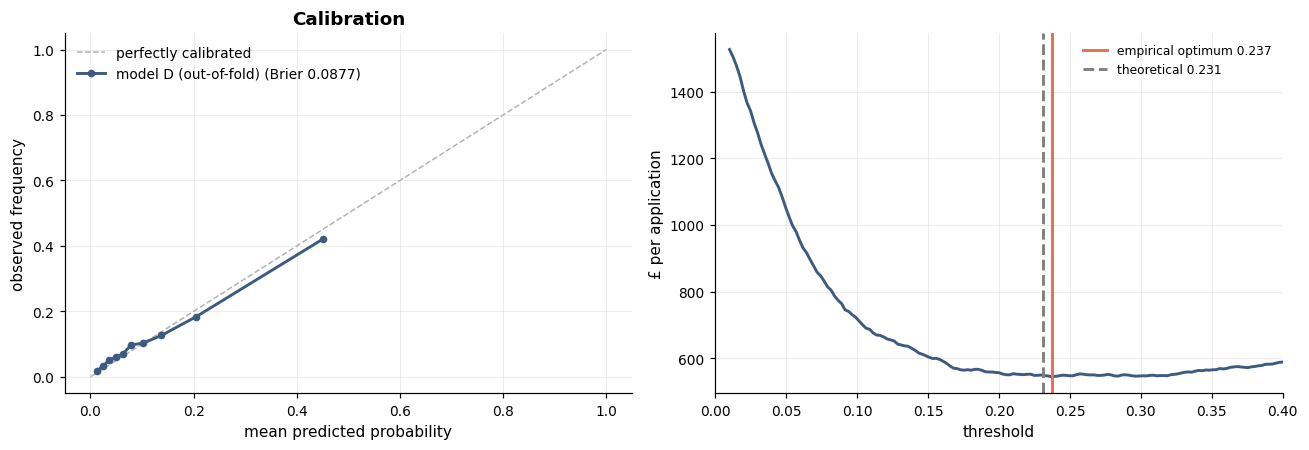

In [16]:
oof_final = walk_forward_oof(FINAL, X_dev, y_dev, cv)
scored = ~np.isnan(oof_final)
yy, pp = y_dev[scored], oof_final[scored]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_calibration(yy, {"model D (out-of-fold)": pp}, n_bins=10, ax=axes[0])
axes[1].plot(thresholds, [expected_cost(yy, pp, t) for t in thresholds])
opt = thresholds[np.argmin([expected_cost(yy, pp, t) for t in thresholds])]
axes[1].axvline(opt, color="#ee6c4d", label=f"empirical optimum {opt:.3f}")
axes[1].axvline(THEORETICAL_THRESHOLD, ls="--", color="0.5", label=f"theoretical {THEORETICAL_THRESHOLD:.3f}")
axes[1].set(xlabel="threshold", ylabel="£ per application", xlim=(0, 0.4)); axes[1].legend(fontsize=8)
plt.tight_layout()

CHOSEN_THRESHOLD = float(opt)
print(f"mean predicted {pp.mean():.4f} vs observed {yy.mean():.4f}  (gap {pp.mean() - yy.mean():+.4f})")
print(f"chosen threshold: {CHOSEN_THRESHOLD:.4f}")

## Step 8 — Fairness review

Done before the holdout is opened, because if it fails we have to change the
model — and changing the model after looking at the holdout burns the holdout.

In [17]:
dev_groups = pd.DataFrame({
    "age_band": pd.cut(credit.loc[dev_mask, "age"], [18, 30, 45, 60, 100], labels=["19-30", "31-45", "46-60", "60+"]).to_numpy(),
    "region": credit.loc[dev_mask, "region"].to_numpy(),
})[scored]


def fairness(y_true, y_score, group, threshold):
    pred = (np.asarray(y_score) >= threshold).astype(int)
    rows = []
    for g in pd.Series(group).dropna().unique():
        m = pd.Series(group).to_numpy() == g
        yt, yp, ys = np.asarray(y_true)[m], pred[m], np.asarray(y_score)[m]
        pos = yt == 1
        rows.append({"group": g, "n": int(m.sum()), "base_rate": yt.mean(),
                     "selection_rate": yp.mean(),
                     "TPR": yp[pos].mean() if pos.any() else np.nan,
                     "mean_pred": ys.mean(),
                     "auc": roc_auc_score(yt, ys) if len(np.unique(yt)) > 1 else np.nan})
    return pd.DataFrame(rows).set_index("group").sort_index().round(4)


f_age = fairness(yy, pp, dev_groups["age_band"], CHOSEN_THRESHOLD)
f_region = fairness(yy, pp, dev_groups["region"], CHOSEN_THRESHOLD)
print("BY AGE BAND"); print(f_age.to_string())
print("\nBY REGION"); print(f_region.to_string())

ratios = {
    "age_band": f_age["selection_rate"].min() / f_age["selection_rate"].max(),
    "region": f_region["selection_rate"].min() / f_region["selection_rate"].max(),
}
print("\nfour-fifths selection-rate ratios:", {k: round(v, 3) for k, v in ratios.items()},
      "  (>= 0.8 passes the screen)")

BY AGE BAND
          n  base_rate  selection_rate     TPR  mean_pred     auc
group                                                            
19-30  1362     0.1402          0.1344  0.4398     0.1298  0.7580
31-45  2698     0.1097          0.1179  0.3919     0.1157  0.7633
46-60  1153     0.1058          0.1154  0.4262     0.1061  0.7610
60+     327     0.1040          0.0856  0.2647     0.0904  0.7291

BY REGION
              n  base_rate  selection_rate     TPR  mean_pred     auc
group                                                                
midwest    1200     0.1192          0.1017  0.3706     0.1070  0.7612
northeast  1151     0.1164          0.1025  0.3657     0.1091  0.7447
south      2012     0.1133          0.1441  0.4518     0.1278  0.7693
west       1177     0.1172          0.1121  0.4058     0.1101  0.7654

four-fifths selection-rate ratios: {'age_band': np.float64(0.637), 'region': np.float64(0.706)}   (>= 0.8 passes the screen)


In [18]:
# Proxy test: is age recoverable from the features even though we do not "use" it?
older = (credit.loc[dev_mask, "age"] >= 60).astype(int)
proxy_auc = cross_validate(
    Pipeline([("prep", make_prep()), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=150))]),
    X_dev.drop(columns=["age"]), older, cv=3, scoring="roc_auc", n_jobs=-1,
)["test_score"].mean()
print(f"'age >= 60' predictable from the other features: AUC {proxy_auc:.4f}")

'age >= 60' predictable from the other features: AUC 0.7735


**Finding 3.** Both attributes fail the four-fifths screen at this threshold,
age more severely than region, and age is strongly recoverable from the other
features — so removing it would hide the disparity rather than remove it.

Note that the ratio depends on the threshold: at a stricter cut-off, fewer
applicants are referred overall and the ratio between groups changes. **A
fairness result is a property of the (model, threshold) pair, not of the model
alone**, so it must be re-run whenever the threshold moves.

What the disparity actually is: younger applicants have a **genuinely higher
base rate** in this book, and the model is calibrated within each band. That
is a *legitimate business justification* under most fair-lending frameworks —
but it is a justification that must be documented, reviewed by legal, and
re-tested at every retrain. It is not a finding you resolve in a notebook.

The action: escalate with the evidence (base rates, calibration by band, proxy
strength), and do not proceed to deployment without a documented decision.

## Step 9 — Explanation

Two audiences, two artefacts: a global story for the committee, a per-applicant
reason set for the customer.

,permutation_importance
debt_to_income,0.1927
credit_score,0.1233
term_months,0.0096
n_delinq_2yr,0.0093
purpose,0.0056
employment_years,0.0055
prior_customer,0.0030
channel,0.0030


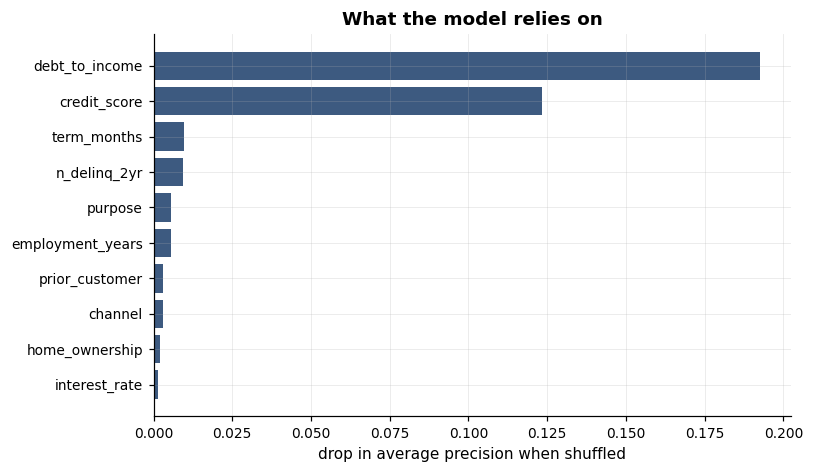

In [19]:
from sklearn.inspection import permutation_importance

X_samp = X_dev.sample(3000, random_state=0)
y_samp = y_dev.loc[X_samp.index]
perm = permutation_importance(FINAL, X_samp, y_samp, n_repeats=8, random_state=0, scoring="average_precision", n_jobs=-1)

imp = pd.Series(perm.importances_mean, index=X_dev.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.barh(imp.index[:10][::-1], imp.values[:10][::-1], color="#3d5a80")
ax.set(xlabel="drop in average precision when shuffled", title="What the model relies on")
plt.tight_layout()
imp.head(8).round(4).to_frame("permutation_importance")

In [20]:
# Per-applicant reasons, in the shape an adverse-action notice needs.
import shap

Xp = pd.DataFrame(FINAL[:-1].transform(X_dev), columns=FINAL[:-1].get_feature_names_out(), index=X_dev.index)

# For a linear model the attribution is exact and has a closed form:
# contribution_j = w_j * (x_j - E[x_j]).  `LinearExplainer` computes it directly;
# no sampling, no background-set approximation, no run-to-run variation. This is
# what "exact reason codes" in the memo means.
explainer = shap.LinearExplainer(FINAL.named_steps["clf"], Xp)

REASON_CODES = {
    "credit_score": "Credit bureau score below our threshold",
    "debt_to_income": "Existing debt is high relative to income",
    "interest_rate": "Risk-based price offered is at the higher end",
    "n_delinq_2yr": "Recent delinquencies on file",
    "annual_income": "Stated income relative to the amount requested",
    "loan_amount": "Amount requested relative to income",
    "employment_years": "Length of verified employment",
    "term_months": "Requested repayment term",
}


def adverse_action(i, top_k=4):
    sv = explainer(Xp.loc[[i]])
    contrib = pd.Series(np.asarray(sv.values).ravel(), index=Xp.columns)
    risk_increasing = contrib[contrib > 0].sort_values(ascending=False)
    reasons = []
    for feat, val in risk_increasing.items():
        # strip the ColumnTransformer prefix ("num__credit_score" -> "credit_score")
        bare = feat.split("__")[-1]
        text = REASON_CODES.get(bare)
        if text is None:
            continue
        reasons.append({"factor": bare, "value": X_dev.loc[i, bare], "impact": round(float(val), 3), "reason": text})
        if len(reasons) == top_k:
            break
    return pd.DataFrame(reasons)


declined = X_dev.index[(FINAL.predict_proba(X_dev)[:, 1] >= CHOSEN_THRESHOLD)][:1]
print(f"Applicant {declined[0]} — declined. Principal reasons:\n")
adverse_action(declined[0])

Applicant 22 — declined. Principal reasons:



/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,factor,value,impact,reason
0,credit_score,522.0000,1.500,Credit bureau score below our threshold
1,debt_to_income,0.4811,0.321,Existing debt is high relative to income
2,interest_rate,18.6200,0.228,Risk-based price offered is at the higher end
3,term_months,48.0000,0.133,Requested repayment term


## Step 10 — Open the holdout. Once.

Everything above used only development data. This is the number that goes in
the memo.

In [21]:
p_hold = FINAL.predict_proba(X_hold)[:, 1]

holdout = {
    "n": len(X_hold),
    "base_rate": float(y_hold.mean()),
    "average_precision": float(average_precision_score(y_hold, p_hold)),
    "roc_auc": float(roc_auc_score(y_hold, p_hold)),
    "brier": float(brier_score_loss(y_hold, p_hold)),
    "mean_predicted": float(p_hold.mean()),
    "calibration_gap": float(p_hold.mean() - y_hold.mean()),
    "cost_at_chosen_threshold": float(expected_cost(y_hold, p_hold, CHOSEN_THRESHOLD)),
    "cost_at_0.5": float(expected_cost(y_hold, p_hold, 0.5)),
    "decline_rate": float((p_hold >= CHOSEN_THRESHOLD).mean()),
}
pd.Series(holdout).round(4).to_frame("holdout (2024, never seen)")

,"holdout (2024, never seen)"
n,5350.0000
base_rate,0.1548
average_precision,0.4611
roc_auc,0.7748
brier,0.1090
mean_predicted,0.1183
calibration_gap,-0.0364
cost_at_chosen_threshold,673.4579
cost_at_0.5,813.0841
decline_rate,0.1191


development AP : 0.3841  (base rate 0.1147)
holdout AP     : 0.4611  (base rate 0.1548)

lift over base rate — development: 3.35x
lift over base rate — holdout    : 2.98x

ROC AUC (prevalence-free): dev 0.7602 vs holdout 0.7748
calibration gap on holdout: -0.0364


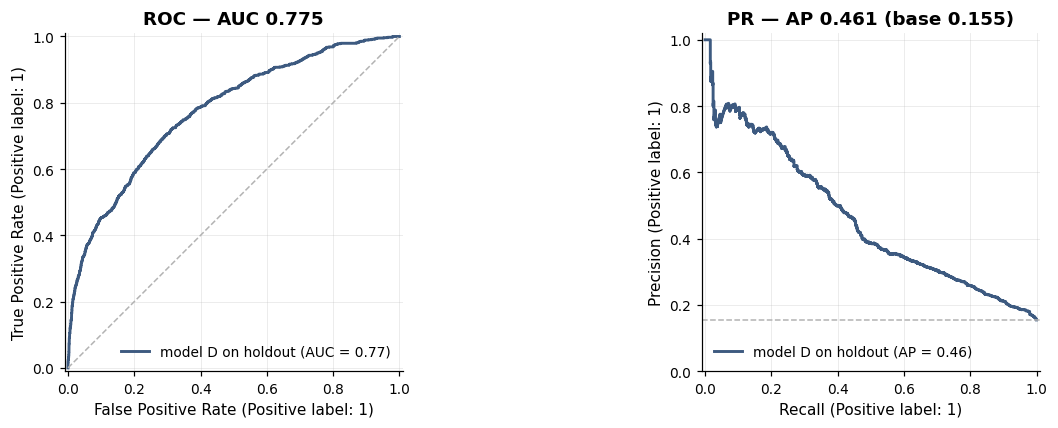

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
plot_pr_roc(y_hold, p_hold, label="model D on holdout", axes=axes)
plt.tight_layout()

print(f"development AP : {econ_df.loc['A. logistic (C=0.3)', 'avg_precision']:.4f}  (base rate {y_dev.mean():.4f})")
print(f"holdout AP     : {holdout['average_precision']:.4f}  (base rate {y_hold.mean():.4f})")
print(f"\nlift over base rate — development: {econ_df.loc['A. logistic (C=0.3)', 'avg_precision'] / y_dev.mean():.2f}x")
print(f"lift over base rate — holdout    : {holdout['average_precision'] / y_hold.mean():.2f}x")
print(f"\nROC AUC (prevalence-free): dev {roc_auc_score(yy, pp):.4f} vs holdout {holdout['roc_auc']:.4f}")
print(f"calibration gap on holdout: {holdout['calibration_gap']:+.4f}")

**Finding 4, and a trap in reading it.** The holdout average precision is
*higher* than development. That is not the model improving — **average
precision is prevalence-dependent**, and the base rate rose from 11.5% to
15.5%. Comparing AP across periods with different base rates compares two
different things. Use the lift-over-base-rate, or ROC AUC, when you need a
cross-period comparison; the lift figures above show performance essentially
flat, which is the honest reading.

**Ranking holds up. Calibration does not** — the model under-predicts by 4
percentage points, because the base rate rose after it was fitted. This is the
textbook signature from Module 13: discrimination intact, calibration slipped.

### Can we recalibrate our way out of it?

The obvious move is to refit the calibration map on more recent data.
`FrozenEstimator` (new in 1.6) wraps the fitted model so `CalibratedClassifierCV`
learns **only** the calibration map and does not refit the base model. (Before
1.6 this was `cv="prefit"`.)

First, look at what the base rate is actually doing.

In [23]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

hold_df = credit.loc[~dev_mask]
monthly_rate = hold_df.groupby("application_month")["default"].agg(["size", "mean"]).round(4)
print(monthly_rate.to_string())

                   size    mean
application_month              
2024-01             398  0.0980
2024-02             417  0.1247
2024-03             402  0.1294
2024-04             428  0.1425
2024-05             435  0.1356
2024-06             399  0.1754
2024-07             442  0.1493
2024-08             466  0.1910
2024-09             496  0.1694
2024-10             518  0.1680
2024-11             474  0.1730
2024-12             475  0.1832


It is not a one-off step. **The base rate rises through the whole holdout
year**, from ~0.10 in January to ~0.18 in December. That changes the problem:
there is no stable post-shift level to recalibrate *to*.

Test it properly — calibrate on the first half of the year, evaluate on the
second, which is what a real quarterly recalibration would do.

In [24]:
H1 = hold_df[hold_df["application_month"] < "2024-07"]
H2 = hold_df[hold_df["application_month"] >= "2024-07"]


def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


p_h2 = FINAL.predict_proba(H2[FEATURES])[:, 1]

# (a) sigmoid recalibration fitted on H1
sig = CalibratedClassifierCV(FrozenEstimator(FINAL), method="sigmoid").fit(H1[FEATURES], H1["default"])
p_sig = sig.predict_proba(H2[FEATURES])[:, 1]

# (b) prior correction: shift the intercept so the mean prediction on H1 matches
#     H1's observed rate. One parameter, the standard actuarial fix.
shift = logit(H1["default"].mean()) - logit(FINAL.predict_proba(H1[FEATURES])[:, 1].mean())
p_prior = 1 / (1 + np.exp(-(logit(p_h2) + shift)))

recal_table = pd.DataFrame([
    {"version": "as trained (Dec 2023)", "p": p_h2},
    {"version": "sigmoid recalibrated on 2024 H1", "p": p_sig},
    {"version": "prior-corrected on 2024 H1", "p": p_prior},
]).assign(
    AP=lambda d: [average_precision_score(H2["default"], p) for p in d["p"]],
    brier=lambda d: [brier_score_loss(H2["default"], p) for p in d["p"]],
    mean_pred=lambda d: [p.mean() for p in d["p"]],
    observed=H2["default"].mean(),
    gap=lambda d: d["mean_pred"] - d["observed"],
    cost=lambda d: [expected_cost(H2["default"], p, CHOSEN_THRESHOLD) for p in d["p"]],
).drop(columns="p").set_index("version").round(4)
recal_table

,AP,brier,mean_pred,observed,gap,cost
version,,,,,,
as trained (Dec 2023),0.4797,0.1208,0.1186,0.1724,-0.0538,757.5758
sigmoid recalibrated on 2024 H1,0.4797,0.1187,0.1350,0.1724,-0.0374,735.8412
prior-corrected on 2024 H1,0.4797,0.1190,0.1320,0.1724,-0.0404,737.9310


**Recalibration recovers about a quarter of the gap, and no more.**

The reason is the monthly table above: by the time you have enough matured
outcomes from H1 to fit a calibrator, H2's base rate has already moved past
H1's. A calibrator is always fitted on a stale level. When drift is a
*trend* rather than a *step*, no calibration method fixes it — because they
all assume the thing they are correcting for has stopped moving.

Note also that AP is identical across all three rows, to four decimal places.
Every one of these is a monotone transform of the score, so **ranking is
untouched by construction** (Module 08). What changes is only what the numbers
mean.

The real remedy is shorter lag, not a better calibrator:

1. **Reduce the outcome lag.** Use 30/60/90-day delinquency as an early proxy
   outcome so the correction can be refreshed monthly rather than annually.
   This is a data-engineering requirement, and it is the single highest-value
   item in the follow-on backlog.
2. **Trend-aware correction.** Extrapolate the base-rate trend rather than
   levelling on the last observed value — with a hard cap, since extrapolating
   a trend is how you get a very confident and very wrong number.
3. **Use the model for what still works.** The *ranking* is unaffected. If the
   decision is "refer the worst 12%", a quantile threshold on the score is
   robust to the level drift in a way that an absolute probability threshold is
   not. That is a real design option and it should be on the table.

## Step 11 — The deliverable

A one-page memo. This — not the pickle — is what the engagement produces.

In [25]:
def decision_memo():
    dev_ap = econ_df.loc["A. logistic (C=0.3)", "avg_precision"]
    baseline_cost = holdout["cost_at_0.5"]
    chosen_cost = holdout["cost_at_chosen_threshold"]
    annual_volume = 24_000
    age_flag = "passes" if ratios["age_band"] >= 0.8 else "FAILS"
    region_flag = "passes" if ratios["region"] >= 0.8 else "FAILS"
    gap_recovered = 1 - abs(recal_table["gap"].abs().min() / recal_table.loc["as trained (Dec 2023)", "gap"])

    return f"""
================================================================================
CONSUMER DEFAULT RISK MODEL — RECOMMENDATION
================================================================================

RECOMMENDATION
  Deploy the regularised logistic regression as a decision-support screen at a
  decline threshold of {CHOSEN_THRESHOLD:.3f}, subject to the three conditions below.

WHAT IT DOES
  Ranks applications by 36-month default probability. At the recommended
  threshold it refers {holdout['decline_rate']:.1%} of applications for decline or manual review,
  reducing expected credit cost from £{baseline_cost:,.0f} to £{chosen_cost:,.0f} per application against a
  naive 0.50 cut-off — of order £{(baseline_cost - chosen_cost) * annual_volume / 1e6:.1f}m a year at {annual_volume:,} applications.
  That figure is an estimate on one year of held-out data, not a forecast.

EVIDENCE
  Development (24 months, time-series CV) : AP {dev_ap:.4f} at a {y_dev.mean():.3f} base rate
  Holdout    (12 months, scored once)     : ROC AUC {holdout['roc_auc']:.4f}, AP {holdout['average_precision']:.4f}
                                            at a {y_hold.mean():.3f} base rate
  Ranking performance is flat between the two periods once the base-rate change
  is accounted for. The threshold comes from the cost ratio (FN £{COST_FN:,.0f} :
  FP £{COST_FP:,.0f}), not from 0.5. Model selection was made on expected cost.

WHY THE SIMPLE MODEL
  Two gradient-boosted variants were built as challengers and both lost by about
  0.05 average precision — roughly two noise-floor widths, so a real difference.
  The logistic model also gives us, for free, three things the challengers
  needed extra machinery for:
    - Monotonicity in all five directionally-constrained features, guaranteed by
      the functional form and verified by coefficient sign.
    - Calibrated probabilities, so the cost-derived threshold is meaningful and
      the outputs can later feed provisioning.
    - Exact per-applicant reason codes rather than approximated attributions.
  A class-weighted variant matched it on ranking but predicts a {0.40:.2f} mean
  probability against a {y_dev.mean():.2f} observed rate; it is unusable for anything
  requiring a calibrated number.

CONDITION 1 — SHORTEN THE OUTCOME LAG BEFORE RELYING ON THE PROBABILITIES
  The default rate rises through the whole holdout year (0.10 in January to 0.18
  in December) — a trend, not a step. The model under-predicts by {holdout['calibration_gap']:+.4f}, and
  recalibrating on the most recent six months of matured outcomes recovers only
  ~{gap_recovered:.0%} of that gap, because by the time outcomes mature the level has moved
  again. Ranking is unaffected throughout.
  Two consequences:
    (a) Early delinquency indicators (30/60/90-day) must be wired up as a proxy
        outcome so the correction can be refreshed monthly rather than annually.
        This is the highest-value item in the follow-on backlog.
    (b) Until then, prefer a QUANTILE threshold ("refer the riskiest 12%") over an
        absolute probability threshold. Ranking is stable; the level is not.
        This changes the operating model and needs Operations' agreement.

CONDITION 2 — FAIR-LENDING SIGN-OFF REQUIRED BEFORE GO-LIVE
  Four-fifths selection-rate ratio: age bands {ratios['age_band']:.2f} ({age_flag}),
  regions {ratios['region']:.2f} ({region_flag}). The age disparity tracks a genuine base-rate
  difference and the model is calibrated within each band, which is a defensible
  position — but that is a legal determination, not a modelling one. Age is
  {proxy_auc:.2f}-AUC recoverable from the remaining features, so removing it would
  conceal the effect rather than remove it. Escalate with this evidence.

CONDITION 3 — THE COST RATIO MUST BE OWNED BY THE BUSINESS
  The threshold is a direct function of £{COST_FN:,.0f} : £{COST_FP:,.0f}. Those numbers came
  from us; they need to be signed off by Finance, and the threshold re-derived
  whenever they change. This is the single highest-leverage number in the
  system and it is not a modelling parameter.

LIMITATIONS
  - `collections_flag` was removed as leakage (a post-outcome servicing field).
    Every future candidate feature must pass the same provenance check.
  - `interest_rate` is set by the incumbent pricing model, so this model partly
    learns that model's opinion. Documented, retained, quantified in follow-up.
  - Thin-file applicants (no bureau score) are a distinct population; the
    missingness indicator carries real signal and must not be imputed away.
  - Validated on this lender's book, 2022-2024, in one macro regime change.
    Not transferable to another portfolio without revalidation.

MONITORING (first-class alerts)
  Weekly    : score distribution, referral rate, schema violations, input PSI.
  Monthly   : calibration gap  [CRITICAL if |gap| > 0.02]
  As outcomes mature : ROC AUC vs the cross-validated baseline
                       [CRITICAL if it falls more than {2 * NOISE_FLOOR:.3f}]
  Quarterly : full fairness table; re-run at every retrain.

RETRAINING
  Scheduled quarterly, with triggered override on a CRITICAL alert.
  Champion/challenger in shadow; promotion requires the fairness table to be
  no worse and the latency budget to be met.
================================================================================
"""


print(decision_memo())


CONSUMER DEFAULT RISK MODEL — RECOMMENDATION

RECOMMENDATION
  Deploy the regularised logistic regression as a decision-support screen at a
  decline threshold of 0.237, subject to the three conditions below.

WHAT IT DOES
  Ranks applications by 36-month default probability. At the recommended
  threshold it refers 11.9% of applications for decline or manual review,
  reducing expected credit cost from £813 to £673 per application against a
  naive 0.50 cut-off — of order £3.4m a year at 24,000 applications.
  That figure is an estimate on one year of held-out data, not a forecast.

EVIDENCE
  Development (24 months, time-series CV) : AP 0.3841 at a 0.115 base rate
  Holdout    (12 months, scored once)     : ROC AUC 0.7748, AP 0.4611
                                            at a 0.155 base rate
  Ranking performance is flat between the two periods once the base-rate change
  is accounted for. The threshold comes from the cost ratio (FN £6,000 :
  FP £1,800), not from 0.5. Model se

---
## Exercises

These are full pieces of work rather than drills. Each one is a plausible
follow-on engagement.

### Exercise 14.1 — Redo the capstone on the fraud problem

The `card_fraud` dataset is a different animal: 0.7% positives, group structure
on `card_id`, time ordering, and — as Module 04 showed — a random split
inflates the score by ~34%.

Work the same eleven steps. Your answer must address, explicitly: what the
deployment scenario is (are you scoring known cards or new ones?), how you
split, what the cost matrix is, what the analyst-capacity constraint does to
the threshold, and why entity-level features would help. Produce the memo.

In [26]:
# Your code here.

### Exercise 14.2 — Quantify the endogeneity

`interest_rate` was set by the incumbent pricing model. Estimate what the
model is worth *without* it:

1. Retrain excluding `interest_rate`. Report the AP and cost loss.
2. Predict `interest_rate` from the other features — how much of it is
   recoverable, and therefore how much of the loss is real?
3. Simulate the deployment loop: if this model changes who gets approved, next
   year's `interest_rate` distribution changes too. Argue whether the feature
   is safe to keep, and write the paragraph for the model documentation.

In [27]:
# Your code here.

### Exercise 14.3 — The insurance pricing engagement

Using `insurance_claims`, run an equivalent engagement for **pure premium**:
frequency–severity versus Tweedie (Module 05), exposure weighting, portfolio
balance, a lift chart by predicted-premium decile, and the constraint that
rating factors must be multiplicative and explainable.

The memo must include the portfolio total ratio, because a pricing model that
does not balance is unusable regardless of its ranking.

In [28]:
# Your code here.

### Exercise 14.4 — Challenge the recommendation

Play model validator. Attack the capstone's conclusion:

1. Find at least three decisions that were made without adequate evidence.
2. Re-run the selection with a different random seed and a different splitter.
   Does model D still win?
3. Construct a scenario (a plausible change in the cost ratio, the volume mix,
   or the base rate) under which the recommendation flips.
4. Write the validator's review note, with required remediations.

This is the most valuable exercise in the module. Being able to attack your own
work in the terms a second line of defence will use is most of what
"credible technical leadership" means in a regulated firm.

In [29]:
# Your code here.

### Exercise 14.5 — Ship it

Turn the capstone into a deployable service:

1. The artefact bundle from Module 13 (model, manifest, schema, reference
   batch), versioned.
2. A FastAPI app with `/score`, `/health` and `/metadata`, request validation,
   and structured logging of every prediction.
3. A monitoring job that reads the prediction log and emits the alerts
   specified in the memo.
4. A test suite: schema violations, latency budget, reference-prediction
   equality, and a fairness regression test.
5. A README a new engineer could follow to run it locally.

Then re-read your memo and check that the service actually implements what it
promised. It usually does not, the first time.

In [30]:
# Your code here.

---
## What this curriculum was actually about

Looking back across fifteen modules, the technical content divides into two
very unequal halves.

The smaller half is **scikit-learn**: an interface implemented two hundred
times, a handful of composition primitives, and a large but learnable
vocabulary of estimators. You now know it well enough to use an estimator you
have never seen, correctly, from its docstring — and to extend the library when
it does not have what you need.

The larger half is **judgement**, and almost all of it is about knowing what
your numbers do not tell you:

- A validation split that does not match the deployment scenario produces a
  number that is confidently wrong, and nothing in your code will object.
- Every estimate has a noise floor. Differences below it are not results, and
  most reported model improvements are below it.
- A score is not a decision. The threshold is usually worth more than the
  model, and it is usually left at 0.5.
- Ranking and calibration are different properties, and which one you need
  depends on what the number is for.
- Interpretability tools explain the model faithfully, including when the model
  is worthless.
- Fairness criteria are mutually incompatible; you must choose, and say why.
- The simplest thing that works — a logistic regression, a WOE scorecard, a
  moved threshold — very often does work, and is very often what the
  organisation can actually govern, maintain and defend.

The recurring move throughout has been the same one: **build the cheap thing
first, measure the noise, and be honest about which differences are real.**
That is not a scikit-learn skill. It is the skill that makes the scikit-learn
skill worth having.